In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\Akanksha\OneDrive\Desktop\Data Science\Data Analytics\Customer Shopping Behavior Analysis\Customer_Shopping.csv")

In [3]:
print(df.head())

   Customer_ID  Customer_Age Gender Product_Name Product_Category  \
0            1            55   Male       Blouse         Clothing   
1            2            19   Male      Sweater         Clothing   
2            3            50   Male        Jeans         Clothing   
3            4            21   Male      Sandals         Footwear   
4            5            45   Male       Blouse         Clothing   

   Purchase_Amount_USD Customer_Location Product_Size Product_Color  \
0                   53          Kentucky            L          Gray   
1                   64             Maine            L        Maroon   
2                   73     Massachusetts            S        Maroon   
3                   90      Rhode Island            M        Maroon   
4                   49            Oregon            M     Turquoise   

  Purchase_Season  Review_Rating Subscription_Status  Shipping_Type  \
0          Winter            3.1                 Yes        Express   
1          Winte

In [4]:
print(df.shape)

(3900, 19)


In [5]:
print(df.columns)

Index(['Customer_ID', 'Customer_Age', 'Gender', 'Product_Name',
       'Product_Category', 'Purchase_Amount_USD', 'Customer_Location',
       'Product_Size', 'Product_Color', 'Purchase_Season', 'Review_Rating',
       'Subscription_Status', 'Shipping_Type', 'Discount_Applied',
       'Promo_Code_Used', 'Previous_Purchases', 'Payment_Method',
       'Purchase_Frequency', 'Purchase_Count'],
      dtype='object')


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer_ID          3900 non-null   int64  
 1   Customer_Age         3900 non-null   int64  
 2   Gender               3900 non-null   object 
 3   Product_Name         3900 non-null   object 
 4   Product_Category     3900 non-null   object 
 5   Purchase_Amount_USD  3900 non-null   int64  
 6   Customer_Location    3900 non-null   object 
 7   Product_Size         3900 non-null   object 
 8   Product_Color        3900 non-null   object 
 9   Purchase_Season      3900 non-null   object 
 10  Review_Rating        3863 non-null   float64
 11  Subscription_Status  3900 non-null   object 
 12  Shipping_Type        3900 non-null   object 
 13  Discount_Applied     3900 non-null   object 
 14  Promo_Code_Used      3900 non-null   object 
 15  Previous_Purchases   3900 non-null   i

In [7]:
df.describe()

,Customer_ID,Customer_Age,Purchase_Amount_USD,Review_Rating,Previous_Purchases,Purchase_Count
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000,3900.0
mean,1950.500000,44.068462,59.764359,3.750065,25.351538,1.0
std,1125.977353,15.207589,23.685392,0.716983,14.447125,0.0
min,1.000000,18.000000,20.000000,2.500000,1.000000,1.0
25%,975.750000,31.000000,39.000000,3.100000,13.000000,1.0
50%,1950.500000,44.000000,60.000000,3.800000,25.000000,1.0
75%,2925.250000,57.000000,81.000000,4.400000,38.000000,1.0
max,3900.000000,70.000000,100.000000,5.000000,50.000000,1.0


In [8]:
# missing values

df.isnull().sum()

Customer_ID             0
Customer_Age            0
Gender                  0
Product_Name            0
Product_Category        0
Purchase_Amount_USD     0
Customer_Location       0
Product_Size            0
Product_Color           0
Purchase_Season         0
Review_Rating          37
Subscription_Status     0
Shipping_Type           0
Discount_Applied        0
Promo_Code_Used         0
Previous_Purchases      0
Payment_Method          0
Purchase_Frequency      0
Purchase_Count          0
dtype: int64

In [9]:
# find percentage 

df.isnull().mean() * 100

Customer_ID            0.000000
Customer_Age           0.000000
Gender                 0.000000
Product_Name           0.000000
Product_Category       0.000000
Purchase_Amount_USD    0.000000
Customer_Location      0.000000
Product_Size           0.000000
Product_Color          0.000000
Purchase_Season        0.000000
Review_Rating          0.948718
Subscription_Status    0.000000
Shipping_Type          0.000000
Discount_Applied       0.000000
Promo_Code_Used        0.000000
Previous_Purchases     0.000000
Payment_Method         0.000000
Purchase_Frequency     0.000000
Purchase_Count         0.000000
dtype: float64

In [10]:
# Duplicate Check  

df.duplicated().sum()

0

In [13]:
# remove duplicate 

df.drop_duplicates(inplace=True)

In [14]:
# basic EDA
# Total Sales

total_sales = df['Purchase_Amount_USD'].sum()

print("Total Sales:", total_sales)

Total Sales: 233081


In [15]:
# Average Purchase 

average_purchase = df['Purchase_Amount_USD'].mean()

print("Average Purchase:", average_purchase)

Average Purchase: 59.76435897435898


In [16]:
#Total Purchases

total_purchases = df['Purchase_Count'].sum()

print('Total Purchases:',total_purchases)

Total Purchases: 3900


In [18]:
# Category Analysis

category_sales = (
    df.groupby('Product_Category')
    ['Purchase_Amount_USD']
    .sum()
    .sort_values(ascending = False)
)

print(category_sales)

Product_Category
Clothing       104264
Accessories     74200
Footwear        36093
Outerwear       18524
Name: Purchase_Amount_USD, dtype: int64


In [19]:
# Product Analysis

product_sales = (
    df.groupby('Product_Name')
    ['Purchase_Amount_USD']
    .sum()
    .sort_values(ascending = False)
)

print(product_sales)
                                 

Product_Name
Blouse        10410
Shirt         10332
Dress         10320
Pants         10090
Jewelry       10010
Sunglasses     9649
Belt           9635
Scarf          9561
Sweater        9462
Shorts         9433
Skirt          9402
Hat            9375
Coat           9275
Socks          9252
Jacket         9249
T-shirt        9248
Shoes          9240
Sandals        9200
Boots          9018
Handbag        8857
Hoodie         8767
Backpack       8636
Sneakers       8635
Gloves         8477
Jeans          7548
Name: Purchase_Amount_USD, dtype: int64


In [21]:
#location Analysis

location_sales = (
    df.groupby('Customer_Location')
      ['Purchase_Amount_USD']
      .sum()
      .sort_values(ascending=False)
)

print(location_sales)

Customer_Location
Montana           5784
Illinois          5617
California        5605
Idaho             5587
Nevada            5514
Alabama           5261
New York          5257
North Dakota      5220
West Virginia     5174
Nebraska          5172
New Mexico        5014
Minnesota         4977
Pennsylvania      4926
Mississippi       4883
Alaska            4867
Vermont           4860
Louisiana         4848
Virginia          4842
Arkansas          4828
Maryland          4795
Tennessee         4772
Delaware          4758
North Carolina    4742
Texas             4712
Missouri          4691
Indiana           4655
Ohio              4649
Georgia           4645
Washington        4623
Michigan          4533
Utah              4443
South Carolina    4439
Kentucky          4402
Maine             4388
Massachusetts     4384
Oklahoma          4376
Arizona           4326
Wyoming           4309
Oregon            4243
South Dakota      4236
Connecticut       4226
Colorado          4222
New Hampshire   

In [22]:
# season analysis

season_sales = (
    df.groupby('Purchase_Season')
      ['Purchase_Amount_USD']
      .sum()
      .sort_values(ascending = False)
)

print(season_sales)

Purchase_Season
Fall      60018
Spring    58679
Winter    58607
Summer    55777
Name: Purchase_Amount_USD, dtype: int64


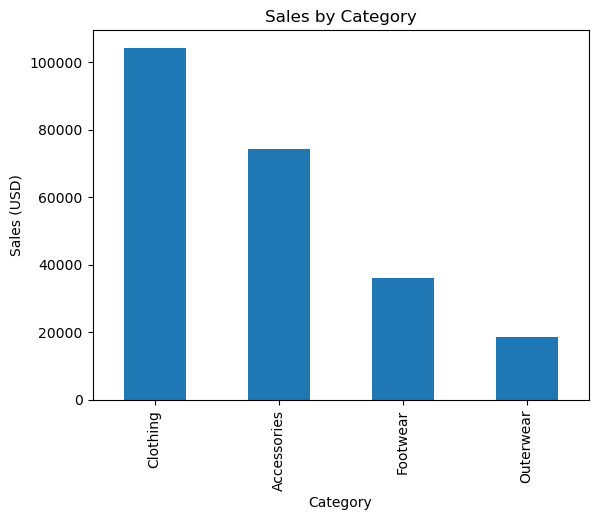

In [23]:
# Python Visualization

# Category chart

category_sales.plot(kind='bar')

plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales (USD)')
plt.show()

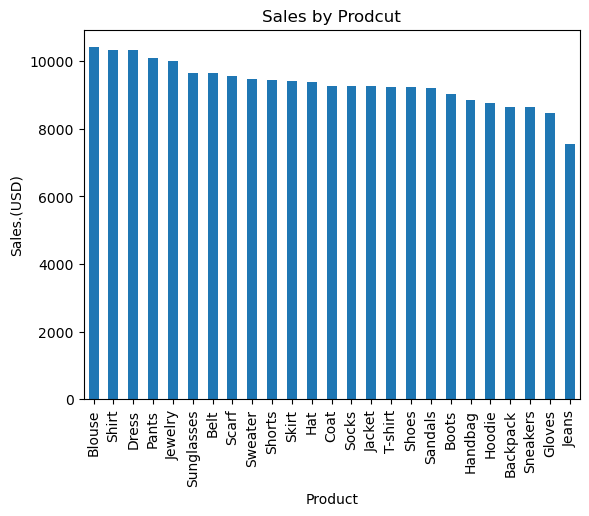

In [24]:
# Product Chart

product_sales.plot(kind='bar')

plt.title('Sales by Prodcut')
plt.xlabel('Product')
plt.ylabel('Sales.(USD)')
plt.show()

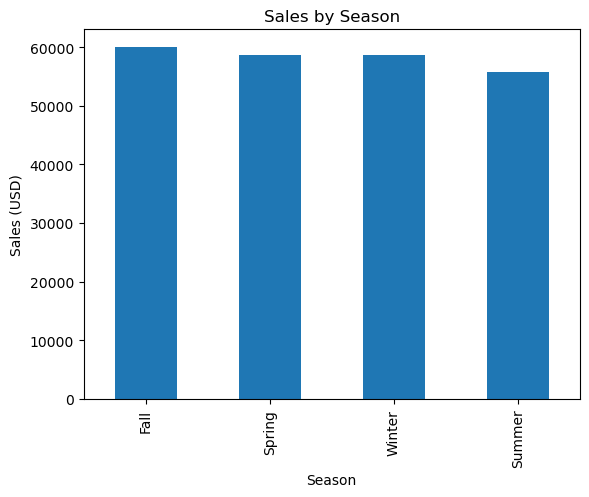

In [25]:
# Season Chart

season_sales.plot(kind='bar')

plt.title('Sales by Season')
plt.xlabel('Season')
plt.ylabel('Sales (USD)')
plt.show()